# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

# Colab: clone fork (có sẵn submission_2A202602727/) rồi chuyển vào thư mục code/ để các đường dẫn tương đối bên dưới vẫn đúng
if "google.colab" in sys.modules:
    COLAB_REPO = "/content/K4-Track4-Day1-Neuralnetwork"
    if not os.path.isdir(COLAB_REPO):
        subprocess.run(["git", "clone", "https://github.com/nhat-thang/K4-Track4-Day1-Neuralnetwork.git", COLAB_REPO], check=True)
    os.chdir(f"{COLAB_REPO}/submission_2A202602727/code")
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)

# Chọn device: "cuda" nếu có GPU, nếu không thì "mps" (Mac), cuối cùng là "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("PyTorch:", torch.__version__)
print("device :", device)
if device == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))

# Thư mục đầu ra (= submission_2A202602727/figures, results)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

# Kiểm tra đường dẫn trước khi sang Part 0
print("REPO_ROOT:", os.path.abspath(REPO_ROOT))
print("OUT_DIR  :", os.path.abspath(OUT_DIR))
assert os.path.isfile(f"{REPO_ROOT}/scripts/split_data.py"), "REPO_ROOT không trỏ về gốc repo"
assert os.path.isdir(f"{REPO_ROOT}/data"), "không thấy thư mục data/ trong REPO_ROOT"
assert os.path.basename(os.path.abspath(OUT_DIR)) == "submission_2A202602727", "OUT_DIR phải là thư mục nộp"

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch: 2.11.0+cu130
device : cuda
GPU    : Tesla T4
REPO_ROOT: /content/K4-Track4-Day1-Neuralnetwork
OUT_DIR  : /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602727


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# ===== Part 0: chia dữ liệu, tách val, chuẩn hoá, đưa lên device =====
subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# Kích thước / kiểu dữ liệu đúng như GUIDE
assert data["X_tr"].shape == (371_847, 54) and data["X_val"].shape == (92_962, 54)
assert data["X_eval"].shape == (116_203, 54)
for k in ("X_tr", "X_val", "X_eval"):
    assert data[k].dtype == torch.float32
for k in ("y_tr", "y_val", "y_eval"):
    assert data[k].dtype == torch.int64 and int(data[k].min()) >= 0 and int(data[k].max()) <= 6

# eval_row_id vẫn khớp thứ tự mẫu eval (so lại với file gốc)
ev = np.load(f"{REPO_ROOT}/data/processed/eval.npz")
assert np.array_equal(data["eval_row_id"], ev["row_id"])
assert np.array_equal(data["y_eval"].cpu().numpy(), ev["y"])
print("eval_row_id:", data["eval_row_id"][:5], "... (len =", len(data["eval_row_id"]), ")")

# Thống kê 10 cột số trên X_tr sau chuẩn hoá ≈ 0 / 1; cột nhị phân giữ nguyên 0/1
num = data["X_tr"][:, :10]
print("mean 10 cột số (X_tr):", np.round(num.mean(0).cpu().numpy(), 4))
print("std  10 cột số (X_tr):", np.round(num.std(0, unbiased=False).cpu().numpy(), 4))
assert torch.allclose(num.mean(0), torch.zeros(10, device=num.device), atol=1e-3)
assert torch.allclose(num.std(0, unbiased=False), torch.ones(10, device=num.device), atol=1e-3)
assert set(torch.unique(data["X_tr"][:, 10:]).tolist()) <= {0.0, 1.0}
# Trên val, mean/std chỉ xấp xỉ 0/1 (không bằng đúng) vì thống kê lấy từ X_tr
print("mean 10 cột số (X_val):", np.round(data["X_val"][:, :10].mean(0).cpu().numpy(), 4))

# Mốc thấp nhất: luôn đoán lớp đa số của train
maj = int(torch.bincount(data["y_tr"], minlength=7).argmax())
maj_acc = (data["y_val"] == maj).float().mean().item()
print(f"Majority baseline (lớp {maj}) — val acc = {maj_acc:.4f}  (GUIDE ≈ 0.4876)")

# Kiểm tra iterate_batches: đủ mẫu, lô cuối nhỏ hơn được giữ lại
from data import iterate_batches
g = torch.Generator(device=data["X_tr"].device).manual_seed(0)
sizes = [len(xb) for xb, _ in iterate_batches(data["X_tr"], data["y_tr"], 512, generator=g)]
print(f"{len(sizes)} lô / epoch, lô cuối = {sizes[-1]} mẫu, tổng = {sum(sizes)}")
assert sum(sizes) == len(data["X_tr"])


tr   : X (371847, 54) torch.float32, y (371847,) torch.int64, device=cuda:0
val  : X (92962, 54) torch.float32, y (92962,) torch.int64, device=cuda:0
eval : X (116203, 54) torch.float32, y (116203,) torch.int64, device=cuda:0
majority baseline (lớp 1) val acc = 0.4876
eval_row_id: [10 11 12 23 34] ... (len = 116203 )
mean 10 cột số (X_tr): [-0. -0. -0.  0. -0. -0. -0. -0. -0.  0.]
std  10 cột số (X_tr): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
mean 10 cột số (X_val): [ 0.0024  0.0021 -0.0024  0.0004 -0.0005  0.0063 -0.0044  0.0022  0.0052
  0.0042]
Majority baseline (lớp 1) — val acc = 0.4876  (GUIDE ≈ 0.4876)
727 lô / epoch, lô cuối = 135 mẫu, tổng = 371847


**Nhận xét Part 0:**
- Kích thước: train 371 847, val 92 962 (20% phân tầng theo nhãn, seed 42), eval 116 203; `X` float32 (N, 54), `y` int64 trong 0..6.
- Chuẩn hoá: mean/std của 10 cột số tính **chỉ trên `X_tr`**, rồi áp dụng cùng mean/std cho train, val, eval; 44 cột nhị phân giữ nguyên. Cột có std = 0 thì chỉ trừ mean (chia cho 1) để tránh chia 0. `apply_standardizer` trả về bản sao, không sửa mảng gốc.
- Vì sao val/eval không tham gia tính mean/std: val và eval đóng vai dữ liệu "chưa thấy". Nếu dùng chúng để tính thống kê, thông tin phân phối của chúng rò rỉ vào bước tiền xử lý (data leakage) → điểm val/eval bị lạc quan và không còn là ước lượng trung thực cho dữ liệu mới. *Áp dụng* phép biến đổi lên val/eval là bắt buộc (model cần đầu vào cùng thang đo); *dùng* chúng để fit phép biến đổi thì không được phép.
- Mốc "luôn đoán lớp đa số" (lớp 1) trên val ≈ 0.4876: mọi model phải vượt xa mức này.
- Lô cuối: giữ lại (không drop_last). Với batch 512, 371 847 = 726·512 + 135 nên mỗi epoch có 727 lô, lô cuối 135 mẫu. Loss CE lấy trung bình trong lô nên lô nhỏ chỉ làm gradient bước đó nhiễu hơn một chút, đổi lại mọi mẫu đều được dùng mỗi epoch.
- `eval_row_id` được giữ nguyên thứ tự mẫu eval (đã đối chiếu với file `eval.npz`) để ghép dự đoán ở Part 4.


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
Số tham số: 47879
  net.0.weight (256, 54)
  net.0.bias   (256,)
  net.2.weight (128, 256)
  net.2.bias   (128,)
  net.4.weight (7, 128)
  net.4.bias   (7,)

input           : (8, 54)
Linear          : (8, 256)
ReLU            : (8, 256)
Linear          : (8, 128)
ReLU            : (8, 128)
Linear          : (8, 7)

Loss bước 0 trên val = 2.3776   (mốc ln 7 = 1.9459, lệch +0.4317)
std của logits bước 0 = 0.647, acc bước 0 = 0.0512

Chuẩn gradient sau một lần backward():
  net.0.weight grad_norm = 0.582299
  net.0.bias   grad_norm = 0.383307
  net.2.weight grad_norm = 2.371695
  net.2.bias   grad_norm = 0.498140
  net.4.weight grad_norm = 2.078331
  net.4.bias   grad_norm = 0.606070

Nhãn của 20 mẫu: [1, 1, 1, 6, 1, 0, 1, 0, 0, 6, 1, 2, 6, 2, 1

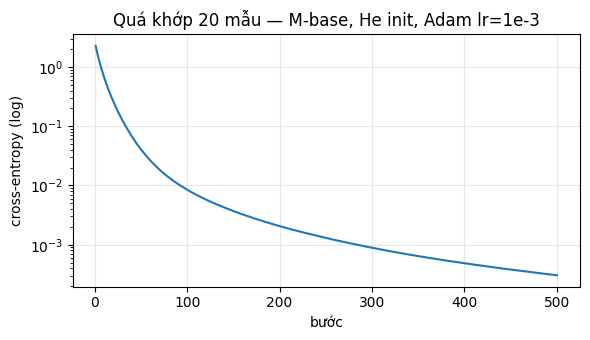

In [3]:
# ===== Part 1: M-base và các phép kiểm tra "sức khoẻ" =====
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- 1. Tạo M-base, kiểm tra số tham số
torch.manual_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
print(model)
print("Số tham số:", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
for name, p in model.named_parameters():
    print(f"  {name:12s} {tuple(p.shape)}")

# --- 2. Một lô ngẫu nhiên (8, 54): in shape sau từng lớp
x = torch.randn(8, 54, device=device)
h = x
print("\ninput           :", tuple(h.shape))
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:16s}:", tuple(h.shape))
logits = model(x)
assert logits.shape == (8, 7) and logits.dtype == torch.float32

# --- 3. Loss bước 0 trên toàn bộ val (eval mode, trước mọi bước cập nhật)
model.eval()
with torch.no_grad():
    val_logits = model(data["X_val"])
    loss0 = F.cross_entropy(val_logits, data["y_val"]).item()
print(f"\nLoss bước 0 trên val = {loss0:.4f}   (mốc ln 7 = {math.log(7):.4f}, lệch {loss0 - math.log(7):+.4f})")
print(f"std của logits bước 0 = {val_logits.std().item():.3f}, acc bước 0 = {(val_logits.argmax(1) == data['y_val']).float().mean().item():.4f}")

# --- 4. Kiểm tra gradient: một lần backward trên một lô train 512 mẫu (model mới, chưa cập nhật)
model.train()
model.zero_grad()
xb, yb = data["X_tr"][:512], data["y_tr"][:512]
F.cross_entropy(model(xb), yb).backward()
print("\nChuẩn gradient sau một lần backward():")
for name, p in model.named_parameters():
    g = None if p.grad is None else p.grad.norm().item()
    print(f"  {name:12s} grad_norm = {g:.6f}" if g is not None else f"  {name:12s} grad = None")
    assert p.grad is not None and g > 0, f"{name} không nhận được gradient"

# --- 5. Quá khớp 20 mẫu: tắt dropout, Adam lr 1e-3, 500 bước, cùng 20 mẫu mỗi bước
torch.manual_seed(42)
overfit_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.randperm(len(data["X_tr"]), device=device)[:20]
x20, y20 = data["X_tr"][idx], data["y_tr"][idx]
print("\nNhãn của 20 mẫu:", y20.tolist())
opt = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)
overfit_losses = []
overfit_model.train()
for step in range(500):
    opt.zero_grad()
    loss = F.cross_entropy(overfit_model(x20), y20)
    loss.backward()
    opt.step()
    overfit_losses.append(loss.item())
    if step in (0, 49, 99, 199, 299, 499):
        print(f"  bước {step + 1:3d}: loss = {loss.item():.6f}")
overfit_model.eval()
with torch.no_grad():
    acc20 = (overfit_model(x20).argmax(1) == y20).float().mean().item()
print(f"Loss cuối = {overfit_losses[-1]:.6f}, accuracy trên 20 mẫu = {acc20:.2%}")
assert overfit_losses[-1] < 0.01 and acc20 == 1.0

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, len(overfit_losses) + 1), overfit_losses)
ax.set_yscale("log")
ax.set_xlabel("bước"); ax.set_ylabel("cross-entropy (log)")
ax.set_title("Quá khớp 20 mẫu — M-base, He init, Adam lr=1e-3")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/figures/part1_overfit20.png", dpi=120)
plt.show()


**Nhận xét Part 1:**
- Kiến trúc: `54 → 256 → 128 → 7`, mọi `Linear` có bias, ReLU sau lớp ẩn, không softmax trong model; số tham số = 47 879, logits shape `(8, 7)`.
- Khởi tạo: `kaiming_normal_(nonlinearity="relu")` (Var = 2/n_in) cho mọi `W`, bias = 0, không phải khởi tạo mặc định của `nn.Linear`.
- Loss bước 0 đo được = **2.3776**, so với ln 7 = 1.9459 (lệch **+0.43**). Nếu mọi logit bằng nhau thì softmax đều 1/7 và CE = ln 7. Ở đây logits có std = **0.647**: chỉ riêng độ phân tán ngẫu nhiên này đã đẩy loss lên khoảng ln 7 + (σ²/2)·(6/7) ≈ 2.13. Phần còn lại (~0.25) nhiều khả năng do một độ lệch chung: 44 cột nhị phân không được trừ mean nên mọi mẫu cùng nghiêng logits về một hướng. Accuracy bước 0 chỉ **0.0512**, thấp hơn cả đoán ngẫu nhiên (≈ 0.14), cho thấy model mới khởi tạo đang đoán lệch có hệ thống về một lớp hiếm. Mức lệch này không phải lỗi: chuẩn hoá đã kiểm tra ở Part 0, gradient chảy tới mọi lớp, và model quá khớp được 20 mẫu. Lệch sẽ lớn hơn nhiều (vài đơn vị) nếu quên chuẩn hoá hoặc lớp cuối khởi tạo quá lớn.
- Quá khớp 20 mẫu: loss giảm từ **2.264** xuống **0.0407** sau 50 bước và **0.000306** sau 500 bước (Adam, lr 1e-3, không dropout), accuracy 100% trên 20 mẫu → model, loss, nhãn và vòng cập nhật (`zero_grad` → `backward` → `step`) phối hợp đúng. Đây chỉ là kiểm tra khả năng khớp, không nói gì về tổng quát hoá.
- Gradient: cả 6 tham số đều có gradient khác `None` và khác 0 sau một lần `backward()` (chuẩn từ 0.38 ở `b1` đến 2.37 ở `W2`) → gradient chảy tới mọi lớp.


## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [ ]:
# TODO: chọn lr cho baseline bằng VAL (chạy vài giá trị, ví dụ quanh 0.01 -> 0.1); ghi bảng lr -> val_macro_f1
# TODO: cfg = {**DEFAULT_CFG, "lr": <lr đã chọn>}
# TODO: chạy baseline với >= 2 seed (khuyến khích 3): result = run_experiment({**cfg, "seed": s, "exp_id": f"base-s{s}"}, data)
# TODO: với mỗi result: save_result(result, f"{OUT_DIR}/results"); plot_run(result, f"{OUT_DIR}/figures/{exp_id}.png")
# TODO: tính trung bình ± độ lệch chuẩn (val_macro_f1, val_acc) qua các seed -> ngưỡng nhiễu 2σ

**Nhận xét baseline (tự viết):** hình dạng đường cong (còn giảm? bắt đầu quá khớp?), val_acc so với mốc "đoán đa số", độ nhiễu giữa các seed ...

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm `<exp_id>` — chủ đề `<nhóm>`
**Dự đoán trước (viết TRƯỚC khi chạy):** ...

In [ ]:
# Mẫu một thí nghiệm. Lặp lại / bọc trong vòng for qua danh sách cfg bạn tự thiết kế.
# TODO: exp_cfg = {**cfg, "exp_id": "...", "group": "...", "description": "...", <chỉ đổi MỘT yếu tố>}
# TODO: result = run_experiment(exp_cfg, data)
# TODO: save_result(...); plot_run(...)   # mỗi thí nghiệm một ảnh figures/<exp_id>.png
# TODO: in summary (best_val_loss, val_acc, val_macro_f1, ...) và so với baseline + ngưỡng nhiễu 2σ

**Đối chiếu sau khi chạy:** khớp / khác dự đoán? vì sao (cơ chế)? chênh lệch có vượt 2σ không? ...

In [ ]:
# TODO: ảnh chồng theo nhóm: plot_compare(list_of_results_in_group, "val_loss", f"{OUT_DIR}/figures/compare_<nhóm>.png")

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# TODO: chọn cấu hình cuối cùng theo VAL (có thể là baseline nếu bạn không kết hợp thêm gì)
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# TODO: results = load_results(f"{OUT_DIR}/results"); rows = [to_row(r, ...) for r in results]
# TODO: write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")
# TODO: bổ sung sheet Seeds (exp_id các lần chạy baseline) và nhận xét ở sheet Summary